In [2]:
# os 환경 변수 GEMINI API KEY 입력
import os
from dotenv import load_dotenv

load_dotenv()

True

[Workflow 공식문서](https://docs.langchain.com/oss/python/langgraph/workflows-agents#orchestrator-worker)

# Prompt Chaining

## Model 정의

In [3]:
from langchain.chat_models import init_chat_model

model = init_chat_model("gpt-5-nano", temperature=1.0)

## State 정의

In [4]:
from typing import TypedDict

class JokeState(TypedDict):
    topic: str          # 초기 주제
    draft_joke: str     # 1단계: 초안
    improved_joke: str  # 2단계: 수정안
    final_joke: str     # 3단계: 최종 결과

## Node 정의

In [5]:
# [Step 1] 초안 생성 노드
def generate_joke(state: JokeState):
    topic = state["topic"]
    print(f"\n--- [1단계] '{topic}' 주제로 농담 초안 생성 중 ---")

    msg = model.invoke(f"'{topic}'에 대한 짧고 재미있는 농담을 하나 만들어줘. 다른 말은 하지 말고 농담 하나만 해")
    return {"draft_joke": msg.content}

In [6]:
# [Step 2] 윤색/수정 노드
def critique_and_improve(state: JokeState):
    original_joke = state["draft_joke"]
    print(f"\n--- [2단계] 더 웃기게 수정 중 (아재개그 스타일) ---")

    prompt = f"""
    다음 농담을 보고, 더 썰렁하고 재미있는 '아재개그' 스타일로 개선해줘. 다른 말은 하지 말고 하나만 답변해.
    원문: {original_joke}
    """
    msg = model.invoke(prompt)
    return {"improved_joke": msg.content}

In [7]:
# [Step 3] 최종 포장 노드
def polish_joke(state: JokeState):
    improved_joke = state["improved_joke"]
    print(f"\n--- [3단계] 이모지 추가 및 마무리 ---")

    prompt = f"""
    다음 농담에 적절한 이모지를 듬뿍 넣어서 SNS에 올리기 좋게 꾸며줘.
    농담: {improved_joke}
    """
    msg = model.invoke(prompt)
    return {"final_joke": msg.content}

## 그래프 생성

In [8]:
from langgraph.graph import StateGraph, START, END

# 그래프 객체 생성
app = StateGraph(JokeState)

# 노드 등록
app.add_node('generate_joke', generate_joke)
app.add_node('critique_and_improve', critique_and_improve)
app.add_node('polish_joke', polish_joke)



# 엣지 연결: 일직선으로 연결 (Linear Chain)
# START -> 1단계 -> 2단계 -> 3단계 -> END
app.add_edge(START, 'generate_joke')
app.add_edge('generate_joke', 'critique_and_improve')
app.add_edge('critique_and_improve', 'polish_joke')
app.add_edge('polish_joke', END)



# 컴파일
chain = app.compile()


/Users/dohyunkim/Documents/langchain-study/langgraph/.venv/lib/python3.13/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


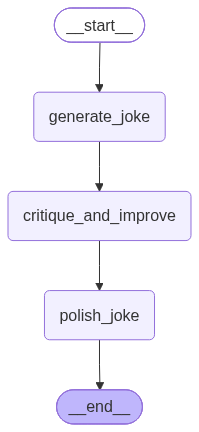

In [9]:
chain

## 실행

In [10]:
inputs = {"topic": "고양이"}
result = chain.invoke(inputs)


--- [1단계] '고양이' 주제로 농담 초안 생성 중 ---

--- [2단계] 더 웃기게 수정 중 (아재개그 스타일) ---

--- [3단계] 이모지 추가 및 마무리 ---


In [11]:
print(f"주제: {result['topic']}")
print(f"1차 초안: {result['draft_joke']}")
print(f"2차 수정: {result['improved_joke']}")
print("-" * 30)
print(f"최종 완성:\n{result['final_joke']}")

주제: 고양이
1차 초안: 고양이가 컴퓨터 앞에 앉아 마우스를 보더니 말한다: "이건 마우스가 아니라 냥스야!"
2차 수정: 고양이가 컴퓨터 앞에 앉아 마우스를 보더니 말한다: "이건 마우스가 아니라 냥스야—클릭하면 야옹 소리가 나거든."
------------------------------
최종 완성:
다음처럼 이모지를 듬뿍 넣은 버전들로 올리면 SNS에 어울려요:

버전 A
😺💻 고양이가 컴퓨터 앞에 앉아 마우스를 보더니 말한다: "이건 마우스가 아니라 냥스야—클릭하면 야옹 소리가 나거든." 🐾🔊🖱️

버전 B
🐈‍⬛✨ 컴퓨터 앞의 냥이, 마우스를 보며 속삭인다: "이건 마우스가 아니라 냥스야—클릭하면 야옹 소리가 나거든." 🖱️🎶😹

버전 C
😽💥 오늘의 IT 비밀: 고양이가 말한다—"이건 마우스가 아니라 냥스야—클릭하면 야옹 소리가 나거든." 🖱️🔊🐾 #고양이농담 #냥스 #야옹소리 #집사일상

원하시면 분위기나 길이에 맞춰 더 변형해 드릴게요.


# Parallelization (병럴 처리)

## Model 정의

In [30]:
model = init_chat_model("gpt-5-nano")

## State 정의

In [31]:
class WriterState(TypedDict):
    topic: str          # 주제
    poem: str           # 시 (결과물 A)
    story: str          # 소설 (결과물 B)
    joke: str           # 농담 (결과물 C)
    final_report: str   # 최종 편집본

## Node 정의

In [32]:
# [Worker A] 시인 노드
def write_poem(state: WriterState):
    topic = state["topic"]
    print(f"   [Worker A] '{topic}' 주제로 시(Poem) 작성 시작...")

    msg = model.invoke(f"'{topic}'에 대한 아름다운 시를 짧게 써줘.")
    return {"poem": msg.content}

In [33]:
# [Worker B] 소설가 노드
def write_story(state: WriterState):
    topic = state["topic"]
    print(f"   [Worker B] '{topic}' 주제로 소설(Story) 작성 시작...")

    msg = model.invoke(f"'{topic}'에 대한 감동적인 짧은 이야기를 써줘.")
    return {"story": msg.content}

In [34]:
# [Worker C] 개그맨 노드
def write_joke(state: WriterState):
    topic = state["topic"]
    print(f"   [Worker C] '{topic}' 주제로 농담(Joke) 작성 시작...")

    msg = model.invoke(f"'{topic}'에 대한 재미있는 아재개그를 하나 해줘.")
    return {"joke": msg.content}

In [35]:
# [Aggregator] 편집장 노드 (모든 결과를 취합)
def aggregator(state: WriterState):
    print("\n--- [Aggregator] 모든 원고 도착! 최종 편집 중 ---")

    # State에 저장된 각 결과물을 꺼내서 합침
    final_text = f"""
    [주제: {state['topic']} 종합 선물세트]

    1. 시 (Poem)
    ----------------
    {state['poem']}

    2. 소설 (Story)
    ----------------
    {state['story']}

    3. 농담 (Joke)
    ----------------
    {state['joke']}
    """
    return {"final_report": final_text}

## 그래프 생성

In [36]:
workflow = StateGraph(WriterState)

# 노드 추가
workflow.add_node('write_poem', write_poem)
workflow.add_node('write_story', write_story)
workflow.add_node('write_joke', write_joke)
workflow.add_node('aggregator', aggregator)


# 엣지 연결: START에서 3개의 노드로 동시에 뻗어 나가기 (Fan-out)
workflow.add_edge(START, 'write_poem')
workflow.add_edge(START, 'write_story')
workflow.add_edge(START, 'write_joke')


# 3개의 노드가 모두 하나의 노드로 모이기 (Fan-in)
workflow.add_edge('write_poem', 'aggregator')
workflow.add_edge('write_story', 'aggregator')
workflow.add_edge('write_joke', 'aggregator')

workflow.add_edge('aggregator', END)

# 컴파일
app = workflow.compile()


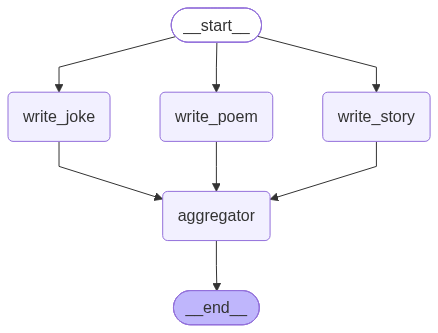

In [37]:
app

## 실행

In [38]:
inputs = {"topic": "직장인의 월요일"}
result = app.invoke(inputs)

   [Worker C] '직장인의 월요일' 주제로 농담(Joke) 작성 시작...   [Worker A] '직장인의 월요일' 주제로 시(Poem) 작성 시작...

   [Worker B] '직장인의 월요일' 주제로 소설(Story) 작성 시작...

--- [Aggregator] 모든 원고 도착! 최종 편집 중 ---


In [39]:
result

{'topic': '직장인의 월요일',
 'poem': '월요일의 직장인, 알람이 도시를 깨운다.\n컵 속 뜨거운 빛이 오늘의 길을 밝히고,\n타자 소리가 심장 박동처럼 흐른다.\n창문 사이로 흘러드는 빛이 말없이 인사를 건네고,\n메모지 위의 잉크가 거리를 한 줄로 엮는다.\n점심의 바람이 틈새를 스치며, 또 한 주의 시작을 속삭인다.',
 'story': '월요일은 늘 그렇듯이, 공기가 조금 무거웠다. 비가 내리면 더 그렇고, 출근길은 늘 지하철의 쇠고동 같은 숨 고르기로 시작된다. 나는 직장인으로서 매주 월요일마다 또 다른 전투를 시작한다. 오늘도 업무 파일이 차곡차곡 쌓여 있고, 이메일 알림은 타이트한 벽처럼 내 뒤를 바짝 따라붙는다. 하지만 오늘은 어제보다는 조금 따뜻한 바람이 흐르는 듯했다.\n\n사무실 문을 열고 들어서자, 신입인 정민이가 쭈뼈대며 내 앞에 섰다. “저, 여기가 발표 자료를 붙이는 곳인가요?” 그의 목소리에 떨림이 묻어 있었다. 그는 발표 파트를 맡았지만 아직 낯선 얼굴들 앞에서 버둥거리고 있었다. 나는 미소로 고개를 끄덕이고, 그의 노트를 한쪽으로 옮겨 보았다. “천천히 가도 괜찮아요. 같이 준비해 봅시다.” 그날은 그가 오늘의 숫자를 이해하고, 내일의 숫자를 차근차근 쌓아 올릴 수 있도록 도운 작은 출발점이었다.\n\n정민은 말없이 내 옆에 앉아 자료를 들여다보았다. “저는 발표가 두려워서요. 사람들이 저를 못 믿을까 봐 걱정돼요.” 그의 말에 무심하게 대답하는 대신, 나는 그의 데이터를 함께 정리해 주고, 말투를 다듬어 주었다. 점심시간이 다가오자 우리는 카페에서 다 같이 도시락을 나눴다. 그는 처음으로 내게 가족 이야기를 털어놓았다. “아버지가 요즘 건강이 좋지 않아요. 그래서 더 빨리 적응하고 싶어요.” 그 말은 내 안의 무게를 살짝 끌어당겼다. 나도 한동안 입 밖으로 꺼내지 못했던 고백을 꺼내듯 조심스레 이야기했다. “저도 비슷한 마음으로 시작했어요. 누군가의 작은 응원이 제게 큰 힘이 되었죠.”\n\n오후의 발표가 다가

In [40]:
result["final_report"]

'\n    [주제: 직장인의 월요일 종합 선물세트]\n\n    1. 시 (Poem)\n    ----------------\n    월요일의 직장인, 알람이 도시를 깨운다.\n컵 속 뜨거운 빛이 오늘의 길을 밝히고,\n타자 소리가 심장 박동처럼 흐른다.\n창문 사이로 흘러드는 빛이 말없이 인사를 건네고,\n메모지 위의 잉크가 거리를 한 줄로 엮는다.\n점심의 바람이 틈새를 스치며, 또 한 주의 시작을 속삭인다.\n\n    2. 소설 (Story)\n    ----------------\n    월요일은 늘 그렇듯이, 공기가 조금 무거웠다. 비가 내리면 더 그렇고, 출근길은 늘 지하철의 쇠고동 같은 숨 고르기로 시작된다. 나는 직장인으로서 매주 월요일마다 또 다른 전투를 시작한다. 오늘도 업무 파일이 차곡차곡 쌓여 있고, 이메일 알림은 타이트한 벽처럼 내 뒤를 바짝 따라붙는다. 하지만 오늘은 어제보다는 조금 따뜻한 바람이 흐르는 듯했다.\n\n사무실 문을 열고 들어서자, 신입인 정민이가 쭈뼈대며 내 앞에 섰다. “저, 여기가 발표 자료를 붙이는 곳인가요?” 그의 목소리에 떨림이 묻어 있었다. 그는 발표 파트를 맡았지만 아직 낯선 얼굴들 앞에서 버둥거리고 있었다. 나는 미소로 고개를 끄덕이고, 그의 노트를 한쪽으로 옮겨 보았다. “천천히 가도 괜찮아요. 같이 준비해 봅시다.” 그날은 그가 오늘의 숫자를 이해하고, 내일의 숫자를 차근차근 쌓아 올릴 수 있도록 도운 작은 출발점이었다.\n\n정민은 말없이 내 옆에 앉아 자료를 들여다보았다. “저는 발표가 두려워서요. 사람들이 저를 못 믿을까 봐 걱정돼요.” 그의 말에 무심하게 대답하는 대신, 나는 그의 데이터를 함께 정리해 주고, 말투를 다듬어 주었다. 점심시간이 다가오자 우리는 카페에서 다 같이 도시락을 나눴다. 그는 처음으로 내게 가족 이야기를 털어놓았다. “아버지가 요즘 건강이 좋지 않아요. 그래서 더 빨리 적응하고 싶어요.” 그 말은 내 안의 무게를 살짝 끌어당겼다. 나도 한동안 입 밖으로 꺼내지 못했던 